# Proyecto Final – Detección de Fraude con Tarjetas de Crédito

## 1. Introducción

La detección de fraude es un problema crítico en el ámbito financiero. El fraude representa una parte muy pequeña de las transacciones, pero sus consecuencias son grandes. Por ello, necesitamos modelos capaces de identificar la clase minoritaria.

**Objetivos del proyecto:**

- Analizar el dataset y el desbalance de clases.
- Entrenar un modelo base (Regresión Logística) y un modelo más complejo (Random Forest).
- Evaluar con métricas adecuadas (precision, recall, F1 y ROC-AUC).

## 2. Descripción del dataset

El archivo `creditcard.csv` contiene transacciones reales:

- **Time**: segundos desde la primera transacción.
- **Amount**: importe de la transacción.
- **V1 – V28**: variables transformadas con PCA.
- **Class**: 0 (legítima), 1 (fraude).

In [1]:
# Imports básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Carga del dataset
# Asegúrate de que creditcard.csv esté en el mismo directorio

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Información rápida
print(df.shape)
df.info()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [4]:
# Desbalance de clases
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


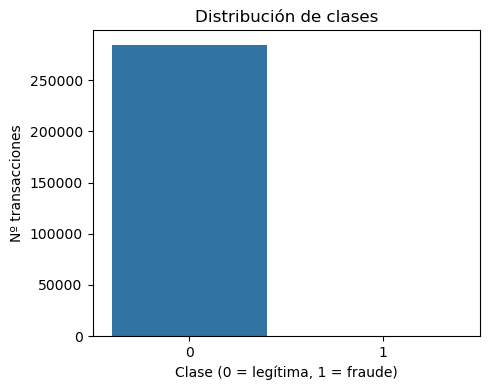

In [5]:
# Visualización del desbalance
plt.figure(figsize=(5, 4))
sns.countplot(x="Class", data=df)
plt.title("Distribución de clases")
plt.xlabel("Clase (0 = legítima, 1 = fraude)")
plt.ylabel("Nº transacciones")
plt.tight_layout()
plt.show()

**Nota:** en un dataset tan desbalanceado, la **accuracy** puede ser engañosa. Por eso usaremos métricas centradas en la clase minoritaria.

## 3. Preprocesado de datos

- Separamos variables (X) y etiqueta (y).
- Escalamos las columnas `Time` y `Amount`.
- Dividimos en train/test con estratificación.

In [6]:
# Separación de variables y etiqueta
X = df.drop(columns=["Class"])
y = df["Class"]

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Escalado simple para Time y Amount
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

## 4. Modelos utilizados

### 4.1 Regresión Logística (modelo base)

Modelo sencillo y rápido. Usamos `class_weight='balanced'` para compensar el desbalance.

In [8]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### 4.2 Random Forest (modelo más complejo)

Modelo basado en árboles, capaz de capturar relaciones no lineales. También se usa `class_weight='balanced'`.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## 5. Evaluación

Métricas utilizadas:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Matriz de confusión**

In [10]:
def evaluar_modelo(modelo, X_test, y_test, nombre="Modelo"):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(4, 3))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - {nombre}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return precision, recall, f1, roc_auc

=== Regresión Logística ===
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



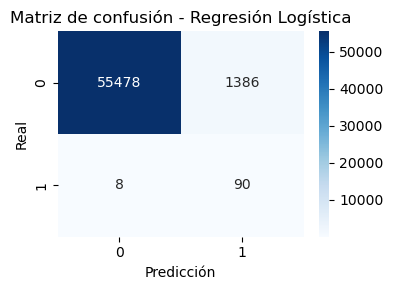

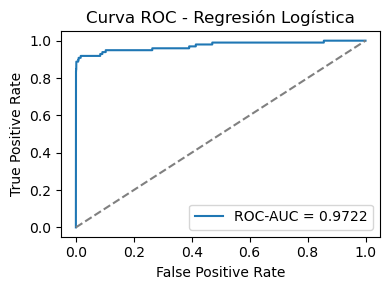

In [12]:
metrics_log = evaluar_modelo(log_reg, X_test, y_test, "Regresión Logística")

=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962



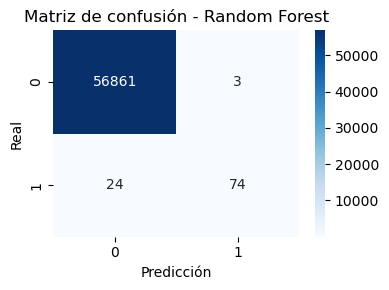

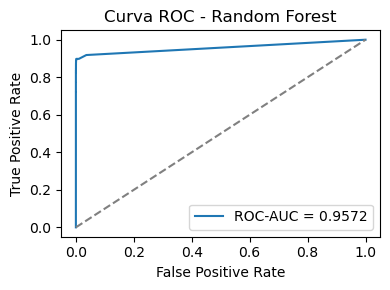

In [11]:
metrics_rf = evaluar_modelo(rf, X_test, y_test, "Random Forest")

## 6. Comparación de resultados

In [13]:
results = pd.DataFrame(
    [metrics_log, metrics_rf],
    columns=["Precision", "Recall", "F1-score", "ROC-AUC"],
    index=["Regresión Logística", "Random Forest"]
)
results

,Precision,Recall,F1-score,ROC-AUC
Regresión Logística,0.060976,0.918367,0.114358,0.972169
Random Forest,0.961039,0.755102,0.845714,0.957189


## 7. Conclusiones

Los resultados obtenidos muestran que ambos modelos presentan un comportamiento coherente en un problema de detección de fraude con datos altamente desbalanceados. La regresión logística consigue un recall muy alto en la clase minoritaria, lo que permite detectar la mayoría de los fraudes, pero genera un número elevado de falsos positivos.

En cambio, el modelo Random Forest ofrece un mejor equilibrio global, con una precisión muy alta y una reducción drástica de falsas alarmas, aunque con una ligera pérdida de recall. Por ello, y teniendo en cuenta el compromiso entre detección y eficiencia, Random Forest se considera el modelo más adecuado como solución final.